I.) Load data and data cleaning

1.) Import libraries


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import GEOparse

2.) Load PFC mRNA data into a dataframe

In [3]:
pfc_mrna_file = "data/GSE22521_series_matrix.txt"


pfc_mrna = pd.read_csv(
    pfc_mrna_file,
    sep="\t",
    comment="!",
    index_col=0
)

3.) Have a look at the data

In [5]:
print(pfc_mrna.shape)

print(pfc_mrna.head())

(13042, 68)
         GSM559183  GSM559184  GSM559185  GSM559186  GSM559187  GSM559188  \
ID_REF                                                                      
7896822   3.924486   4.209343   2.558671   4.434798   3.664290   3.628356   
7897034   4.363519   4.345616   3.768352   2.571772   4.083087   4.760077   
7897044   4.601810   5.095022   4.617025   4.396065   4.889153   4.575935   
7897068   3.806804   3.950793   3.108032   4.385707   3.521073   3.809370   
7897078   5.362968   5.503288   5.244282   5.053874   5.328000   5.461167   

         GSM559189  GSM559190  GSM559191  GSM559192  ...  GSM559241  \
ID_REF                                               ...              
7896822   2.824752   3.433710   2.164794   2.957314  ...   2.536889   
7897034   4.256415   4.144009   3.522481   4.214889  ...   3.627683   
7897044   4.763925   4.740030   4.369615   4.968942  ...   4.439761   
7897068   3.074784   3.629333   2.836160   3.097626  ...   3.419544   
7897078   5.422790   5

In [7]:
round(pfc_mrna.describe(),2)

,GSM559183,GSM559184,GSM559185,GSM559186,GSM559187,GSM559188,GSM559189,GSM559190,GSM559191,GSM559192,...,GSM559241,GSM559242,GSM559243,GSM559244,GSM559245,GSM559246,GSM559247,GSM559248,GSM559249,GSM559250
count,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,...,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00,13042.00
mean,3.89,3.87,3.82,3.87,3.83,3.89,3.84,3.87,3.82,3.82,...,3.87,3.83,3.87,3.79,3.84,3.81,3.85,3.85,3.82,3.82
std,1.68,1.68,1.73,1.64,1.74,1.67,1.71,1.70,1.70,1.74,...,1.70,1.69,1.64,1.69,1.69,1.70,1.72,1.69,1.71,1.71
min,-0.96,-1.40,-2.05,-1.26,-1.05,-1.18,-2.40,-1.88,-2.12,-2.72,...,-1.19,-2.01,-2.12,-1.58,-1.59,-2.22,-1.76,-2.22,-1.91,-2.18
25%,2.73,2.70,2.53,2.74,2.57,2.73,2.58,2.67,2.54,2.52,...,2.61,2.59,2.71,2.52,2.62,2.52,2.60,2.61,2.56,2.55
50%,3.89,3.86,3.80,3.89,3.83,3.90,3.84,3.88,3.78,3.80,...,3.87,3.82,3.86,3.78,3.83,3.77,3.84,3.80,3.78,3.79
75%,5.06,5.04,5.08,5.00,5.06,5.06,5.08,5.07,5.04,5.07,...,5.08,5.02,5.00,5.02,5.04,5.05,5.08,5.06,5.04,5.06
max,9.22,10.31,10.04,10.25,9.66,9.57,9.58,9.52,9.68,9.49,...,9.91,10.21,10.25,9.49,10.39,9.67,9.78,9.60,9.54,10.09


4.) The info Table S1 states 61 individuals, but the array shows 68. 4 were tested twice. That means there is still a discrepancy. We have to fnd out which onese were taken out. We will use GEOparse on the info file "_family.soft"

In [19]:
gse = GEOparse.get_GEO(
    filepath="data/GSE22521_family.soft",
    include_data=True,
    silent=False
) 

09-Oct-2026 19:52:42 INFO GEOparse - Parsing data/GSE22521_family.soft: 
09-Oct-2026 19:52:42 DEBUG GEOparse - DATABASE: GeoMiame
09-Oct-2026 19:52:42 DEBUG GEOparse - SERIES: GSE22521
09-Oct-2026 19:52:42 DEBUG GEOparse - PLATFORM: GPL6244
09-Oct-2026 19:52:48 DEBUG GEOparse - SAMPLE: GSM559183
09-Oct-2026 19:52:48 DEBUG GEOparse - SAMPLE: GSM559184
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559185
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559186
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559187
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559188
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559189
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559190
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559191
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559192
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559193
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559194
09-Oct-2026 19:52:49 DEBUG GEOparse - SAMPLE: GSM559195
09-Oct-2026 19:52:49 DEBUG GEOp

5.) GEOparse creates a Python object containing the study information. gse.gsms is a a Python dictionary containing the sample objects. We check how many there are.

In [20]:
print(type(gse))
print(gse.name)
print(len(gse.gsms))

<class 'GEOparse.GEOTypes.GSE'>
GSE22521
68


6.) We check the metadata for one individual

In [36]:
test_ind = gse.gsms["GSM559248"]

print( f"Name : {test_ind.name}")
print( f"Metadata : {test_ind.metadata}")
print( f"Table : {test_ind.table}")
print( f"Columns : {test_ind.columns}")



Name : GSM559248
Metadata : {'title': ['Chimpanzee - superior frontal gyrus - 4500 days old'], 'geo_accession': ['GSM559248'], 'status': ['Public on Dec 09 2011'], 'submission_date': ['Jun 23 2010'], 'last_update_date': ['Dec 09 2011'], 'type': ['RNA'], 'channel_count': ['1'], 'source_name_ch1': ['Dissected Chimpanzee post-mortem superior frontal gyrus'], 'organism_ch1': ['Pan troglodytes'], 'taxid_ch1': ['9598'], 'characteristics_ch1': ['age: 4500 days', 'gender: m', 'tissue: superior frontal gyrus of the brain', 'post-mortem interval (hours): -', 'rna integrity number (rin): 5.9', 'batch: 1'], 'biomaterial_provider_ch1': ['BPRC, Rijswijk, Netherlands'], 'treatment_protocol_ch1': ['All human postmortem brain tissue samples were obtained from the NICHD Brain and Tissue Bank for Developmental Disorders (NICHDBB)(Baltimore, MD, USA). All subjects were defined as normal controls by forensic pathologists at the NICHDBB. No subjects with prolonged agonal state were used. Chimpanzee samples 

7.) We check the metadata to explain the discrepancy.

In [23]:
records = []

for gsm_id, gsm in gse.gsms.items():
    records.append({
        "GSM": gsm_id,
        "Title": gsm.metadata.get("title", [None])[0],
        "Source": gsm.metadata.get("source_name_ch1", [None])[0],
        "Characteristics": gsm.metadata.get("characteristics_ch1", []),
        "Description": gsm.metadata.get("description", [])
    })

sample_info = pd.DataFrame(records)

display(sample_info.head(10))

,GSM,Title,Source,Characteristics,Description
0,GSM559183,Human - superior frontal gyrus - 14309 days old,Dissected Human post-mortem superior frontal g...,"[age: 14309 days, gender: m, tissue: superior ...",[The dataset contains two prenatal individuals...
1,GSM559184,Human - superior frontal gyrus - 1630 days old,Dissected Human post-mortem superior frontal g...,"[age: 1630 days, gender: f, tissue: superior f...",[The dataset contains two prenatal individuals...
2,GSM559185,Human - superior frontal gyrus - 19457 days old,Dissected Human post-mortem superior frontal g...,"[age: 19457 days, gender: m, tissue: superior ...",[The dataset contains two prenatal individuals...
3,GSM559186,Human - superior frontal gyrus - 19 days old,Dissected Human post-mortem superior frontal g...,"[age: 19 days, gender: f, tissue: superior fro...",[The dataset contains two prenatal individuals...
4,GSM559187,Human - superior frontal gyrus - 204 days old,Dissected Human post-mortem superior frontal g...,"[age: 204 days, gender: m, tissue: superior fr...",[The dataset contains two prenatal individuals...
5,GSM559188,Human - superior frontal gyrus - 21204 days old,Dissected Human post-mortem superior frontal g...,"[age: 21204 days, gender: m, tissue: superior ...",[The dataset contains two prenatal individuals...
6,GSM559189,Human - superior frontal gyrus - 24090 days old,Dissected Human post-mortem superior frontal g...,"[age: 24090 days, gender: m, tissue: superior ...",[The dataset contains two prenatal individuals...
7,GSM559190,Human - superior frontal gyrus - 28692 days old,Dissected Human post-mortem superior frontal g...,"[age: 28692 days, gender: f, tissue: superior ...",[The dataset contains two prenatal individuals...
8,GSM559191,Human - superior frontal gyrus - 29200 days old,Dissected Human post-mortem superior frontal g...,"[age: 29200 days, gender: m, tissue: superior ...",[The dataset contains two prenatal individuals...
9,GSM559192,Human - superior frontal gyrus - 2922 days old,Dissected Human post-mortem superior frontal g...,"[age: 2922 days, gender: m, tissue: superior f...",[The dataset contains two prenatal individuals...


In [40]:
print(sample_info[["GSM", "Title"]].to_string(index=False))

sample_info.to_csv("data/pfc_sample_info.csv", index=False)

      GSM                                                              Title
GSM559183                    Human - superior frontal gyrus - 14309 days old
GSM559184                     Human - superior frontal gyrus - 1630 days old
GSM559185                    Human - superior frontal gyrus - 19457 days old
GSM559186                       Human - superior frontal gyrus - 19 days old
GSM559187                      Human - superior frontal gyrus - 204 days old
GSM559188                    Human - superior frontal gyrus - 21204 days old
GSM559189                    Human - superior frontal gyrus - 24090 days old
GSM559190                    Human - superior frontal gyrus - 28692 days old
GSM559191                    Human - superior frontal gyrus - 29200 days old
GSM559192                     Human - superior frontal gyrus - 2922 days old
GSM559193               Human - superior frontal gyrus - 2 days old (batch1)
GSM559194               Human - superior frontal gyrus - 2 days old (batch2)

7.i) Add species and age information to sample_info

In [51]:
sample_info["Species"] = (
    sample_info["Title"]
    .str.extract(r"^(Human|Chimpanzee|Rhesus macaque)", expand=False)
)

sample_info["Age_days"] = pd.to_numeric(
    sample_info["Title"]
    .str.extract(r"(\d+)\s+days?\s+old", expand=False),
    errors="coerce"
)

print(sample_info.head())

sample_info.to_csv("data/pfc_sample_info.csv", index=False)

         GSM                                            Title  \
0  GSM559183  Human - superior frontal gyrus - 14309 days old   
1  GSM559184   Human - superior frontal gyrus - 1630 days old   
2  GSM559185  Human - superior frontal gyrus - 19457 days old   
3  GSM559186     Human - superior frontal gyrus - 19 days old   
4  GSM559187    Human - superior frontal gyrus - 204 days old   

                                              Source  \
0  Dissected Human post-mortem superior frontal g...   
1  Dissected Human post-mortem superior frontal g...   
2  Dissected Human post-mortem superior frontal g...   
3  Dissected Human post-mortem superior frontal g...   
4  Dissected Human post-mortem superior frontal g...   

                                     Characteristics  \
0  [age: 14309 days, gender: m, tissue: superior ...   
1  [age: 1630 days, gender: f, tissue: superior f...   
2  [age: 19457 days, gender: m, tissue: superior ...   
3  [age: 19 days, gender: f, tissue: superior fr

8.) We take the 5 individuals with duplicate measurements and check if they are correlated

In [38]:
duplicate_pairs = pd.DataFrame({
    "GSM1": [
        "GSM559193", "GSM559198", "GSM559208", "GSM559215", "GSM559223"
    ],
    "GSM2": [
        "GSM559194", "GSM559199", "GSM559209", "GSM559216", "GSM559224"
    ]
})


for _, row in duplicate_pairs.iterrows():
    gsm1 = row["GSM1"]
    gsm2 = row["GSM2"]

    correlation = pfc_mrna[gsm1].corr(pfc_mrna[gsm2])

    print(gsm1, gsm2, "Correlation:", round(correlation, 4))

GSM559193 GSM559194 Correlation: 0.9415
GSM559198 GSM559199 Correlation: 0.9454
GSM559208 GSM559209 Correlation: 0.9821
GSM559215 GSM559216 Correlation: 0.9721
GSM559223 GSM559224 Correlation: 0.9764


8.) Another individual was not in Table S1, we identified it using an LLM. It is GSM559211 who is 1487 days or 4 years and 17 days old. 
    We make an exclusion list and a reduced table and check for missing values and duplicates

In [41]:
exclusion_list = ["GSM559194", "GSM559199", "GSM559209", "GSM559216", "GSM559224", "GSM559211"]

In [56]:
pfc_mrna_clean = pfc_mrna.drop(columns=exclusion_list)

pfc_mrna_clean.columns

print(pfc_mrna_clean.isna().sum().sum())

print("Duplicate feature IDs:",
      pfc_mrna_clean.index.duplicated().sum())

print("Duplicate GSM IDs:",
      pfc_mrna_clean.columns.duplicated().sum())


0
Duplicate feature IDs: 0
Duplicate GSM IDs: 0


9.) We make a new metadata table and look at the age distribution

In [52]:
sample_info_clean = sample_info[
    ~sample_info["GSM"].isin(exclusion_list)
].copy()

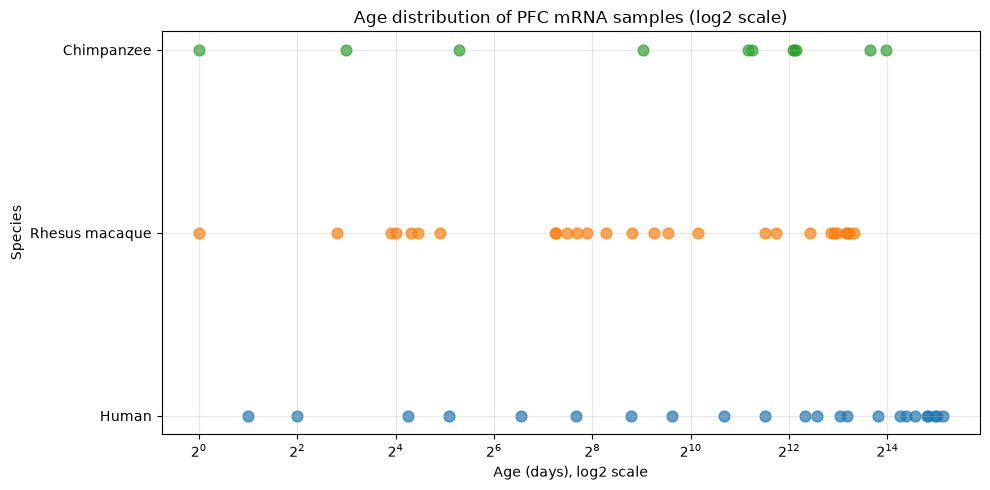

In [54]:
plt.figure(figsize=(10, 5))

for species in sample_info_clean["Species"].unique():
    
    subset = sample_info_clean[
        sample_info_clean["Species"] == species
    ]
    
    plt.scatter(
        subset["Age_days"],
        [species] * len(subset),
        label=species,
        s=60,
        alpha=0.7
    )

plt.xscale("log", base=2)
plt.xlabel("Age (days), log2 scale")
plt.ylabel("Species")
plt.title("Age distribution of PFC mRNA samples (log2 scale)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

10.) Trying to find an outlier macaque. We extract the species data and correlate all individuals

In [64]:
species_ids = {}
corr = {}
median_corr = {}

for i in sample_info_clean["Species"].unique():

    info = sample_info_clean[
        sample_info_clean["Species"] == i
    ].copy()

    species_ids[i] = info["GSM"].tolist()

    spec_mrna = pfc_mrna_clean[species_ids[i]]

    corr[i] = spec_mrna.corr()

    median_corr[i] = corr[i].mask(
        np.eye(len(corr[i]), dtype=bool)
    ).median()

    print(f"\nSpecies: {i}")
    display(median_corr[i].sort_values().head(10))



Species: Human


GSM559193    0.845729
GSM559186    0.877110
GSM559201    0.906572
GSM559191    0.920674
GSM559197    0.921499
GSM559200    0.927352
GSM559207    0.928219
GSM559198    0.928756
GSM559185    0.933086
GSM559202    0.933726
dtype: float64


Species: Rhesus macaque


GSM559225    0.885962
GSM559229    0.922054
GSM559214    0.925741
GSM559232    0.927417
GSM559236    0.929807
GSM559227    0.930108
GSM559226    0.931029
GSM559238    0.931973
GSM559233    0.933965
GSM559235    0.934188
dtype: float64


Species: Chimpanzee


GSM559245    0.917097
GSM559250    0.919824
GSM559242    0.922950
GSM559239    0.928499
GSM559241    0.935504
GSM559243    0.946899
GSM559244    0.947299
GSM559246    0.947619
GSM559240    0.949751
GSM559248    0.953120
dtype: float64

11.) The analysis reveals 3 outliers, 2 humans and 1 macaque, which are taken out. 

In [65]:
outliers = [
    "GSM559193",  # Human, median correlation 0.845729
    "GSM559186",  # Human, median correlation 0.877110
    "GSM559225"   # Macaque, median correlation 0.885962
]

In [68]:
sample_info_clean.loc[
    sample_info_clean["GSM"].isin(outliers)
]

,GSM,Title,Source,Characteristics,Description,Species,Age_days
3,GSM559186,Human - superior frontal gyrus - 19 days old,Dissected Human post-mortem superior frontal g...,"[age: 19 days, gender: f, tissue: superior fro...",[The dataset contains two prenatal individuals...,Human,19
10,GSM559193,Human - superior frontal gyrus - 2 days old (b...,Dissected Human post-mortem superior frontal g...,"[age: 2 days, gender: m, tissue: superior fron...",[The dataset contains two prenatal individuals...,Human,2
42,GSM559225,Rhesus macaque - superior frontal gyrus - -30 ...,Dissected Rhesus macaque post-mortem superior ...,[age: -30 days (prenatal individual; predicted...,[The dataset contains two prenatal individuals...,Rhesus macaque,30


12.) We make a new datatable by taking out the three outliers. Selectin criterion: Median correlation within species higher than 90%

In [73]:
sample_info_filt = sample_info_clean[
    ~sample_info_clean["GSM"].isin(outliers)
].copy()



In [76]:
pfc_mrna_filt = pfc_mrna_clean.drop(columns=outliers)

pfc_mrna_filt.info()


<class 'pandas.DataFrame'>
Index: 13042 entries, 7896822 to 8177222
Data columns (total 59 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GSM559183  13042 non-null  float64
 1   GSM559184  13042 non-null  float64
 2   GSM559185  13042 non-null  float64
 3   GSM559187  13042 non-null  float64
 4   GSM559188  13042 non-null  float64
 5   GSM559189  13042 non-null  float64
 6   GSM559190  13042 non-null  float64
 7   GSM559191  13042 non-null  float64
 8   GSM559192  13042 non-null  float64
 9   GSM559195  13042 non-null  float64
 10  GSM559196  13042 non-null  float64
 11  GSM559197  13042 non-null  float64
 12  GSM559198  13042 non-null  float64
 13  GSM559200  13042 non-null  float64
 14  GSM559201  13042 non-null  float64
 15  GSM559202  13042 non-null  float64
 16  GSM559203  13042 non-null  float64
 17  GSM559204  13042 non-null  float64
 18  GSM559205  13042 non-null  float64
 19  GSM559206  13042 non-null  float64
 20  GSM559207  130

13.) We now match the identifiers to genes using the annotation from the original data 

In [ ]:
# Getting the file using GEOparse

gpl = GEOparse.get_GEO(
    geo="GPL6244",
    destdir="data"
)

annotation = gpl.table.copy()

print(annotation.shape)
display(annotation.head())

09-Oct-2026 23:25:22 DEBUG utils - Directory data already exists. Skipping.
09-Oct-2026 23:25:22 INFO GEOparse - File already exist: using local version.
09-Oct-2026 23:25:22 INFO GEOparse - Parsing data/GPL6244.txt: 
09-Oct-2026 23:25:22 DEBUG GEOparse - PLATFORM: GPL6244


(33297, 12)


,ID,GB_LIST,SPOT_ID,seqname,RANGE_GB,RANGE_STRAND,RANGE_START,RANGE_STOP,total_probes,gene_assignment,mrna_assignment,category
0,7896736,NaN,chr1:53049-54936,chr1,NC_000001.10,+,53049,54936,7,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,NaN,chr1:63015-63887,chr1,NC_000001.10,+,63015,63887,31,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195,NM_001005240,NM_001005484,BC13684...",chr1:69091-70008,chr1,NC_000001.10,+,69091,70008,24,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,"NR_024437,XM_006711854,XM_006726377,XR_430662,...",chr1:334129-334296,chr1,NC_000001.10,+,334129,334296,6,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221,NM_001005224,NM_001005277,NM_0010...",chr1:367659-368597,chr1,NC_000001.10,+,367659,368597,36,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main


In [92]:
# show columns
print(annotation.columns.tolist())

['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


In [ ]:
# show how many expression ids can be found in the annotation

expression_ids = set(pfc_mrna_filt.index.astype(str))
platform_ids = set(annotation["ID"].astype(str))

print("Expression features:", len(expression_ids))

print(
    "Features found in annotation:",
    len(expression_ids & platform_ids)
)

print(
    "Features not found:",
    len(expression_ids - platform_ids)
)

Expression features: 13042
Features found in annotation: 13042
Features not found: 0
